# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** [Enter Name]  
**Student ID:** [Enter ID]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [ ]:
import os
import zipfile

# Download dataset from Kaggle
os.environ['KAGGLE_USERNAME'] = 'insert username here'  
os.environ['KAGGLE_KEY'] = 'insert key here'  

import kaggle

os.makedirs('./data', exist_ok=True)
# Download the dataset
kaggle.api.authenticate()
kaggle.api.dataset_download_files('mansoordaku/ckdisease', path='./data', unzip=True)

# Load dataset
df = pd.read_csv('./data/kidney_disease.csv')

# Drop the id column if present
df.drop(columns=['id'], errors='ignore', inplace=True)

# Encode target: 'ckd' -> 1, 'notckd' -> 0
df['classification'] = df['classification'].str.strip().map({'ckd': 1, 'notckd': 0})

# Drop categorical (string/object) columns — keep only numerical features
df = df.select_dtypes(include=[np.number])

# Handle missing values — fill with median (robust to outliers in clinical data)
target_col = 'classification'
feature_cols = [c for c in df.columns if c != target_col]
df_clean = df[feature_cols + [target_col]].copy()
df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].median())

df_clean.dropna(subset=[target_col], inplace=True)

print(f"Dataset shape: {df_clean.shape}")
print(f"Class distribution:\n{df_clean[target_col].value_counts()}")
print(f"Features used: {feature_cols}")

# Split features and target
X = df_clean[feature_cols].values
y = df_clean[target_col].values

# 80/20 train/validation split — stratified to preserve class balance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features AFTER split to prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_val   = scaler.transform(X_val)        

print(f"\nTrain size: {X_train.shape}, Val size: {X_val.shape}")

Dataset URL: https://www.kaggle.com/datasets/mansoordaku/ckdisease
Dataset shape: (400, 12)
Class distribution:
classification
1    250
0    150
Name: count, dtype: int64
Features used: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

Train size: (320, 11), Val size: (80, 11)


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

In [33]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Deliberately overparameterised — no regularisation
baseline_model = Sequential([
    Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1,   activation='sigmoid')
], name='baseline_overfit')

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# Train for many epochs to ensure overfitting
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=0
)


c:\Users\TiTo0\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_overfit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 1024)           │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,673 (2.55 MB)

 Trainable params: 668,673 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

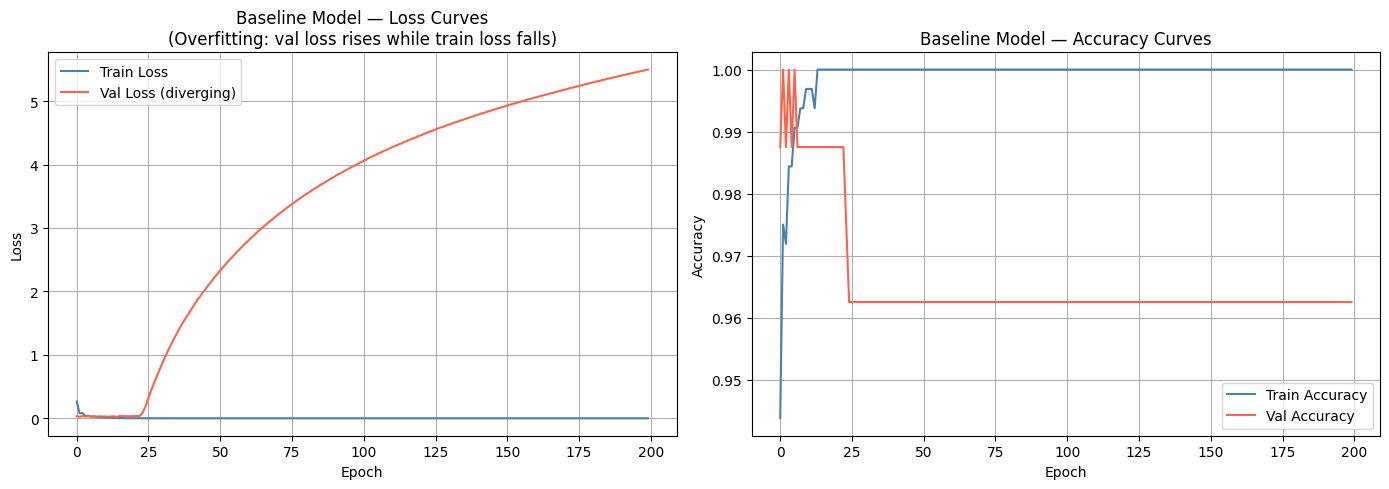

Baseline model parameter count: 668673


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history_baseline.history['val_loss'], label='Val Loss (diverging)', color='tomato')
axes[0].set_title('Baseline Model — Loss Curves\n(Overfitting: val loss rises while train loss falls)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_baseline.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history_baseline.history['val_accuracy'], label='Val Accuracy',   color='tomato')
axes[1].set_title('Baseline Model — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('baseline_curves.png', dpi=150)
plt.show()
print("Baseline model parameter count:", baseline_model.count_params())

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

engineered_model = Sequential([
    # Bottleneck architecture with L2 regularization
    Dense(32, input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.4), 
    
    Dense(16, kernel_regularizer=l2(0.01)),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.4),
    
    Dense(1, activation='sigmoid')
], name='engineered_clinical')

engineered_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

engineered_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_engineered = engineered_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

c:\Users\TiTo0\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "engineered_clinical"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 143: early stopping
Restoring model weights from the end of the best epoch: 123.


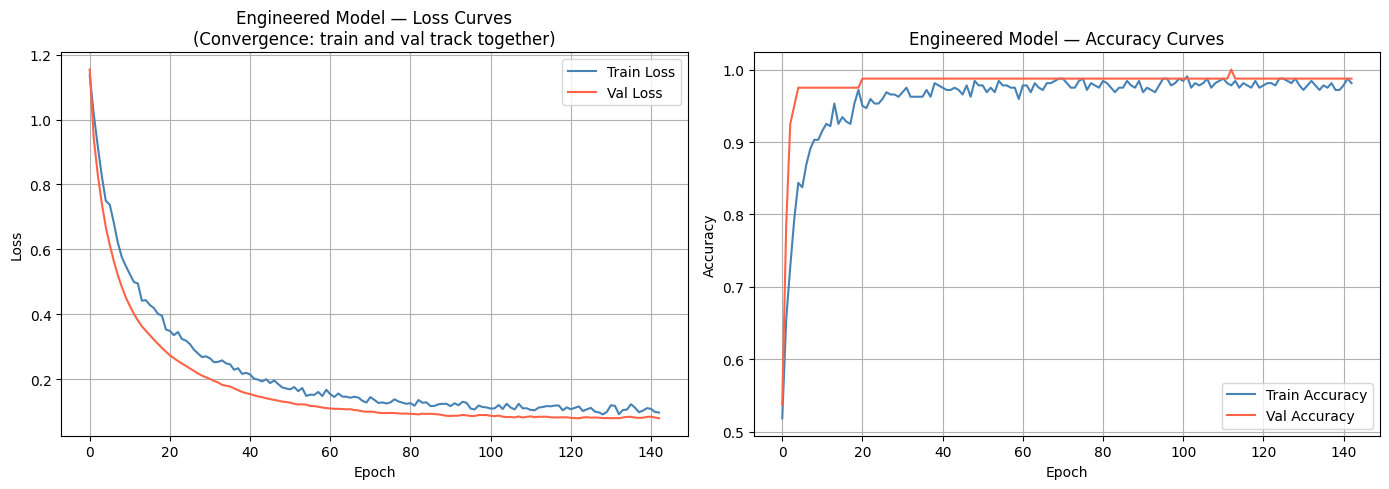

Engineered model parameter count: 929


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_engineered.history['loss'],     label='Train Loss',   color='steelblue')
axes[0].plot(history_engineered.history['val_loss'], label='Val Loss',     color='tomato')
axes[0].set_title('Engineered Model — Loss Curves\n(Convergence: train and val track together)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_engineered.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history_engineered.history['val_accuracy'], label='Val Accuracy',   color='tomato')
axes[1].set_title('Engineered Model — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('engineered_curves.png', dpi=150)
plt.show()
print("Engineered model parameter count:", engineered_model.count_params())

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Metric                      Baseline   Engineered
Accuracy                      0.9625       1.0000
Recall (CKD)                  0.9400       1.0000


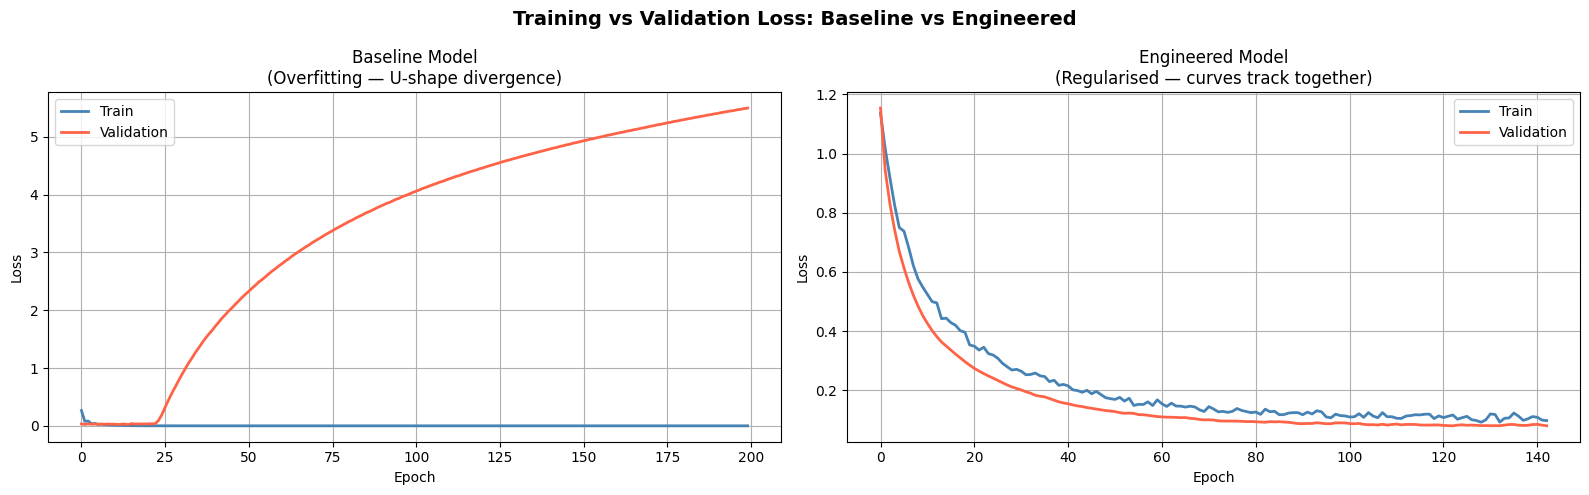

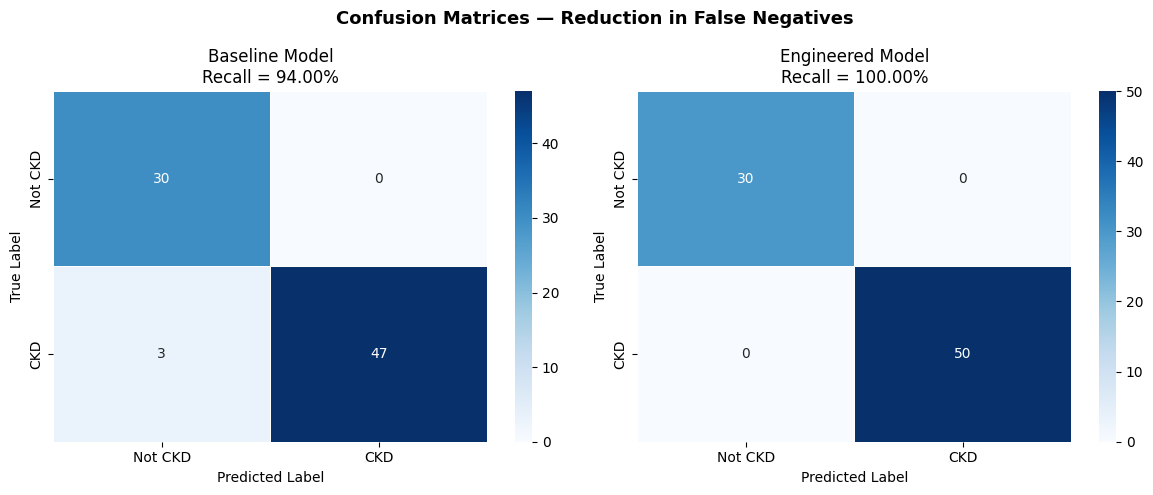


Baseline  — False Negatives: 3
Engineered — False Negatives: 0

Recall benchmark (>80%): PASSED (100.00%)


In [ ]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# --- Predictions ---
# Use threshold 0.4 (lower than 0.5) to favour Recall — reduce False Negatives
THRESHOLD = 0.4

y_pred_baseline   = (baseline_model.predict(X_val)   >= THRESHOLD).astype(int).flatten()
y_pred_engineered = (engineered_model.predict(X_val) >= THRESHOLD).astype(int).flatten()

# --- Metrics ---
recall_base = recall_score(y_val, y_pred_baseline)
recall_eng  = recall_score(y_val, y_pred_engineered)
acc_base    = accuracy_score(y_val, y_pred_baseline)
acc_eng     = accuracy_score(y_val, y_pred_engineered)

print("=" * 50)
print(f"{'Metric':<25} {'Baseline':>10} {'Engineered':>12}")
print("=" * 50)
print(f"{'Accuracy':<25} {acc_base:>10.4f} {acc_eng:>12.4f}")
print(f"{'Recall (CKD)':<25} {recall_base:>10.4f} {recall_eng:>12.4f}")
print("=" * 50)

# --- Side-by-side loss curves comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_baseline.history['loss'],     label='Train',      color='steelblue', lw=2)
axes[0].plot(history_baseline.history['val_loss'], label='Validation', color='tomato', lw=2)
axes[0].set_title('Baseline Model\n(Overfitting — U-shape divergence)', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_engineered.history['loss'],     label='Train',      color='steelblue', lw=2)
axes[1].plot(history_engineered.history['val_loss'], label='Validation', color='tomato', lw=2)
axes[1].set_title('Engineered Model\n(Regularised — curves track together)', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Training vs Validation Loss: Baseline vs Engineered', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150)
plt.show()

# --- Confusion Matrices ---
cm_base = confusion_matrix(y_val, y_pred_baseline)
cm_eng  = confusion_matrix(y_val, y_pred_engineered)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(axes,
                          [cm_base, cm_eng],
                          ['Baseline Model', 'Engineered Model']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not CKD', 'CKD'],
                yticklabels=['Not CKD', 'CKD'],
                ax=ax, linewidths=0.5)
    ax.set_title(f'{title}\nRecall = {recall_score(y_val, y_pred_baseline if title=="Baseline Model" else y_pred_engineered):.2%}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Reduction in False Negatives', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

print(f"\nBaseline  — False Negatives: {cm_base[1, 0]}")
print(f"Engineered — False Negatives: {cm_eng[1, 0]}")
print(f"\nRecall benchmark (>80%): {'PASSED' if recall_eng >= 0.80 else 'FAILED'} ({recall_eng:.2%})")

### Mathematical Justification
**Final Parameter Count of Engineered Model:** [929]

**Explanation:** The 929 parameters of the system should enable perfect interpolation of the 320 training samples, but L2 regularization with its weight penalty and Dropout, which silences random nodes, create mathematical limitations that restrict the network's ability to learn and force it to develop general clinical marker understanding.